<a href="https://colab.research.google.com/github/ChengxuanOuyang/PHAS0056-Machine-Learning/blob/main/CourseWorkC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.decomposition import PCA

# Constants
N_COMPONENTS_LIST = [1, 5, 10, 20, 50, 80, 100, 200, 784]

def load_data():
    """Loads MNIST, normalizes to [0,1], and flattens to (N, 784)."""
    (x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
    x_tr = x_tr.astype("float32").reshape(-1, 784) / 255.0
    x_te = x_te.astype("float32").reshape(-1, 784) / 255.0
    return (x_tr, y_tr), (x_te, y_te)

def build_model():
    """Returns a compiled MLP (784 -> 256 -> 128 -> 10)."""
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def get_reconstructed(pca_obj, data, n_comps):
    """Projects data to latent space and reconstructs using top n_comps."""
    # Transform to latent (N, n_comps)
    latent = pca_obj.transform(data)[:, :n_comps]
    # Inverse transform: latent @ components + mean
    return np.dot(latent, pca_obj.components_[:n_comps]) + pca_obj.mean_

# Global Load
(x_train, y_train), (x_test, y_test) = load_data()
print(f"Data Loaded: {x_train.shape}")

Data Loaded: (60000, 784)


In [21]:
print("--- Task 1: Training Baseline Model (Raw Data) ---")
model_baseline = build_model()
model_baseline.fit(x_train, y_train, batch_size=128, epochs=5, validation_split=0.1, verbose=1)

--- Task 1: Training Baseline Model (Raw Data) ---
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8323 - loss: 0.5742 - val_accuracy: 0.9657 - val_loss: 0.1208
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9571 - loss: 0.1414 - val_accuracy: 0.9740 - val_loss: 0.0821
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9707 - loss: 0.0940 - val_accuracy: 0.9787 - val_loss: 0.0734
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9776 - loss: 0.0717 - val_accuracy: 0.9775 - val_loss: 0.0770
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9816 - loss: 0.0584 - val_accuracy: 0.9787 - val_loss: 0.0681


In [22]:
print("--- Task 2: Fitting PCA ---")
# Fit full PCA first to allow flexible slicing later
pca = PCA(n_components=784)
pca.fit(x_train)
print("PCA Fit Complete.")

--- Task 2: Fitting PCA ---
PCA Fit Complete.


In [23]:
print("--- Task 3: Eval Baseline on N Components ---")
acc_baseline = []

# Pre-compute full transform for efficiency
x_test_pca_full = pca.transform(x_test)

for n in N_COMPONENTS_LIST:
    # Reconstruct manually using top n components
    x_recon = np.dot(x_test_pca_full[:, :n], pca.components_[:n]) + pca.mean_

    _, acc = model_baseline.evaluate(x_recon, y_test, verbose=0)
    acc_baseline.append(acc)
    print(f"N={n:3d} | Acc={acc:.4f}")

--- Task 3: Eval Baseline on N Components ---
N=  1 | Acc=0.1692
N=  5 | Acc=0.6010
N= 10 | Acc=0.8412
N= 20 | Acc=0.9481
N= 50 | Acc=0.9754
N= 80 | Acc=0.9800
N=100 | Acc=0.9801
N=200 | Acc=0.9800
N=784 | Acc=0.9810


In [24]:
print("\n--- Task 4: Retraining on 100 Components ---")
# Create training set from top 100 components
x_train_100 = get_reconstructed(pca, x_train, n_comps=100)

model_100 = build_model()
model_100.fit(x_train_100, y_train, batch_size=128, epochs=5, verbose=1)

print("--- Task 5: Eval Model-100 on N Components ---")
acc_100 = []
for n in N_COMPONENTS_LIST:
    x_recon = np.dot(x_test_pca_full[:, :n], pca.components_[:n]) + pca.mean_
    _, acc = model_100.evaluate(x_recon, y_test, verbose=0)
    acc_100.append(acc)
    print(f"N={n:3d} | Acc={acc:.4f}")


--- Task 4: Retraining on 100 Components ---
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8461 - loss: 0.5302
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9594 - loss: 0.1349
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9693 - loss: 0.0987
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9778 - loss: 0.0748
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9782 - loss: 0.0663
--- Task 5: Eval Model-100 on N Components ---
N=  1 | Acc=0.1699
N=  5 | Acc=0.5777
N= 10 | Acc=0.8406
N= 20 | Acc=0.9507
N= 50 | Acc=0.9760
N= 80 | Acc=0.9811
N=100 | Acc=0.9796
N=200 | Acc=0.9787
N=784 | Acc=0.9789


In [25]:
print("\n--- Task 6: Retraining on 20 Components ---")
# Create training set from top 20 components
x_train_20 = get_reconstructed(pca, x_train, n_comps=20)

model_20 = build_model()
model_20.fit(x_train_20, y_train, batch_size=128, epochs=5, verbose=1)

print("Eval Model-20 on N Components...")
acc_20 = []
for n in N_COMPONENTS_LIST:
    x_recon = np.dot(x_test_pca_full[:, :n], pca.components_[:n]) + pca.mean_
    _, acc = model_20.evaluate(x_recon, y_test, verbose=0)
    acc_20.append(acc)
    print(f"N={n:3d} | Acc={acc:.4f}")


--- Task 6: Retraining on 20 Components ---
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8317 - loss: 0.5712
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9429 - loss: 0.1823
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9547 - loss: 0.1443
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9588 - loss: 0.1291
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9637 - loss: 0.1152
Eval Model-20 on N Components...
N=  1 | Acc=0.1558
N=  5 | Acc=0.6004
N= 10 | Acc=0.8500
N= 20 | Acc=0.9679
N= 50 | Acc=0.9610
N= 80 | Acc=0.9604
N=100 | Acc=0.9591
N=200 | Acc=0.9591
N=784 | Acc=0.9580


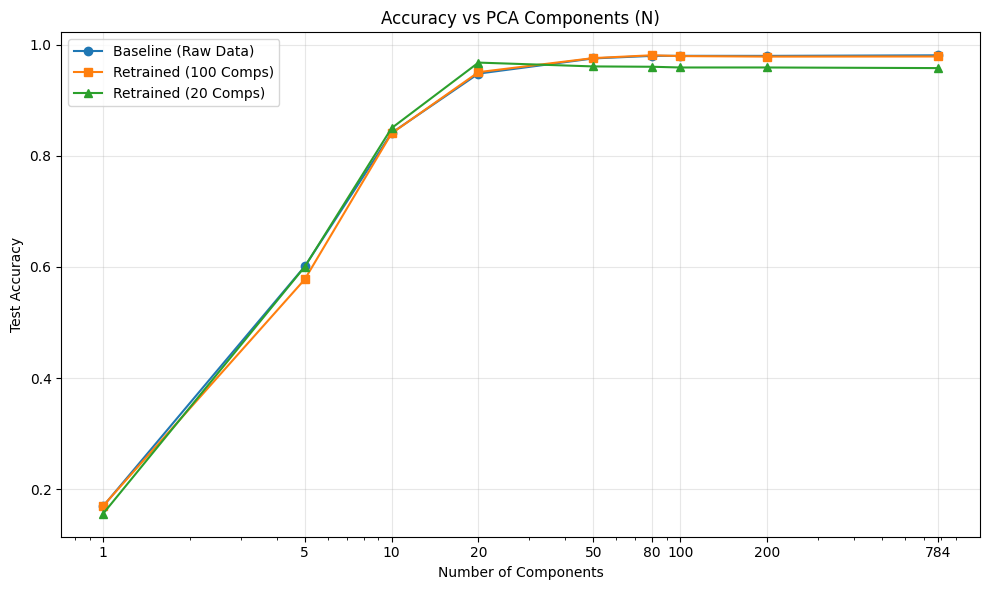

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(N_COMPONENTS_LIST, acc_baseline, 'o-', label='Baseline (Raw Data)')
plt.plot(N_COMPONENTS_LIST, acc_100, 's-', label='Retrained (100 Comps)')
plt.plot(N_COMPONENTS_LIST, acc_20, '^-', label='Retrained (20 Comps)')

plt.title('Accuracy vs PCA Components (N)')
plt.xlabel('Number of Components')
plt.ylabel('Test Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xscale('log') # Log scale helps visualize the lower N values better
plt.xticks(N_COMPONENTS_LIST, labels=N_COMPONENTS_LIST)
plt.tight_layout()
plt.show()